# exP03 第2部分：描述性统计（2.1-2.3）

数据来源：`../data/clean/panel_filtered_winsor_1_5.csv`（1.5 Winsorize后样本）。

本Notebook完成：
1. 2.1 主要变量分组描述统计（全样本、SOE、非SOE）与均值差异t检验；
2. 2.2 Pearson相关系数矩阵与5%显著性标注；
3. 2.3 时序趋势图（Lev均值、NPR均值、Lev分年度箱型图）。

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

DATA_PATH = Path('../data/clean/panel_filtered_winsor_1_5.csv')
OUT_DATA = Path('../data/clean')
OUT_FIG = Path('../output/figures')
OUT_FIG.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH, dtype={'stkcd': str})

# 保证关键变量类型正确
df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')
df['SOE'] = pd.to_numeric(df['SOE'], errors='coerce')

vars_main = ['Lev', 'NPR', 'Size', 'Tang', 'Growth', 'NDTS']
vars_corr = ['Lev', 'NPR', 'Size', 'Tang', 'Growth', 'NDTS', 'SOE']

for c in vars_main + ['SOE']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

print('Data shape:', df.shape)
print('Year range:', int(df['year'].min()), '-', int(df['year'].max()))
print('SOE value counts (incl. NA):')
print(df['SOE'].value_counts(dropna=False).sort_index())

Data shape: (37238, 32)
Year range: 2011 - 2025
SOE value counts (incl. NA):
SOE
0.0000    24934
1.0000    12304
Name: count, dtype: int64


## 2.1 主要变量描述性统计与t检验

In [2]:
def describe_block(data: pd.DataFrame, variables: list[str], group_label: str) -> pd.DataFrame:
    rows = []
    for v in variables:
        s = pd.to_numeric(data[v], errors='coerce').dropna()
        rows.append({
            'Group': group_label,
            'Variable': v,
            'N': int(s.shape[0]),
            'Mean': s.mean(),
            'SD': s.std(ddof=1),
            'P10': s.quantile(0.10),
            'P25': s.quantile(0.25),
            'Median': s.quantile(0.50),
            'P75': s.quantile(0.75),
            'P90': s.quantile(0.90),
        })
    return pd.DataFrame(rows)

desc_all = describe_block(df, vars_main, 'Full')
desc_soe = describe_block(df[df['SOE'] == 1], vars_main, 'SOE')
desc_nonsoe = describe_block(df[df['SOE'] == 0], vars_main, 'Non-SOE')

desc_table = pd.concat([desc_all, desc_soe, desc_nonsoe], ignore_index=True)
desc_table = desc_table[['Group', 'Variable', 'N', 'Mean', 'SD', 'P10', 'P25', 'Median', 'P75', 'P90']]

desc_table.to_csv(OUT_DATA / 'desc_stats_2_1_by_group.csv', index=False, encoding='utf-8-sig')

desc_table

,Group,Variable,N,Mean,SD,P10,P25,Median,P75,P90
0,Full,Lev,37238,0.4028,0.1949,0.1454,0.2445,0.3956,0.5480,0.6696
1,Full,NPR,37238,0.0379,0.0580,-0.0118,0.0141,0.0374,0.0667,0.0998
2,Full,Size,37238,22.2812,1.3402,20.7865,21.3323,22.0598,23.0122,24.0685
3,Full,Tang,37238,0.2051,0.1511,0.0347,0.0878,0.1744,0.2900,0.4208
4,Full,Growth,37238,0.1417,0.2799,-0.0582,0.0071,0.0788,0.1868,0.3828
5,Full,NDTS,37238,0.0251,0.0156,0.0078,0.0135,0.0223,0.0337,0.0461
6,SOE,Lev,12304,0.4814,0.1927,0.2127,0.3349,0.4898,0.6312,0.7370
7,SOE,NPR,12304,0.0330,0.0476,-0.0023,0.0115,0.0301,0.0548,0.0859
8,SOE,Size,12304,23.0410,1.4789,21.2877,21.9610,22.8831,23.9126,24.9630
9,SOE,Tang,12304,0.2363,0.1848,0.0282,0.0827,0.1908,0.3587,0.5244


In [3]:
def p_to_stars(p: float) -> str:
    if p < 0.01:
        return '***'
    if p < 0.05:
        return '**'
    if p < 0.10:
        return '*'
    return ''

ttest_rows = []
for v in vars_main:
    s1 = pd.to_numeric(df.loc[df['SOE'] == 1, v], errors='coerce').dropna()
    s0 = pd.to_numeric(df.loc[df['SOE'] == 0, v], errors='coerce').dropna()
    t_stat, p_val = stats.ttest_ind(s1, s0, equal_var=False, nan_policy='omit')
    diff = s1.mean() - s0.mean()
    ttest_rows.append({
        'Variable': v,
        'Mean(SOE)': s1.mean(),
        'Mean(Non-SOE)': s0.mean(),
        'Diff(SOE-NonSOE)': diff,
        't_stat': t_stat,
        'p_value': p_val,
        'Signif': p_to_stars(p_val),
        'Diff_with_stars': f'{diff:.4f}{p_to_stars(p_val)}'
    })

ttest_table = pd.DataFrame(ttest_rows)
ttest_table.to_csv(OUT_DATA / 'ttest_2_1_soe_vs_nonsoe.csv', index=False, encoding='utf-8-sig')

ttest_table

,Variable,Mean(SOE),Mean(Non-SOE),Diff(SOE-NonSOE),t_stat,p_value,Signif,Diff_with_stars
0,Lev,0.4814,0.3640,0.1174,56.1463,0.0000,***,0.1174***
1,NPR,0.0330,0.0404,-0.0074,-12.6321,0.0000,***,-0.0074***
2,Size,23.0410,21.9062,1.1348,75.6516,0.0000,***,1.1348***
3,Tang,0.2363,0.1898,0.0465,25.1006,0.0000,***,0.0465***
4,Growth,0.1083,0.1582,-0.0499,-17.4460,0.0000,***,-0.0499***
5,NDTS,0.0262,0.0246,0.0016,8.7407,0.0000,***,0.0016***


## 2.2 相关系数矩阵（Pearson）

In [4]:
corr_df = df[vars_corr].dropna().copy()

corr_matrix = corr_df.corr(method='pearson')
pval_matrix = pd.DataFrame(np.ones((len(vars_corr), len(vars_corr))), index=vars_corr, columns=vars_corr)

for i in range(len(vars_corr)):
    for j in range(i + 1, len(vars_corr)):
        x = corr_df[vars_corr[i]]
        y = corr_df[vars_corr[j]]
        r, p = stats.pearsonr(x, y)
        corr_matrix.iloc[i, j] = r
        corr_matrix.iloc[j, i] = r
        pval_matrix.iloc[i, j] = p
        pval_matrix.iloc[j, i] = p

corr_star = corr_matrix.copy().astype(object)
for i in range(len(vars_corr)):
    for j in range(len(vars_corr)):
        if i == j:
            corr_star.iloc[i, j] = '1.0000'
        else:
            r = corr_matrix.iloc[i, j]
            p = pval_matrix.iloc[i, j]
            star = '**' if p < 0.05 else ''
            corr_star.iloc[i, j] = f'{r:.4f}{star}'

corr_matrix.to_csv(OUT_DATA / 'corr_matrix_2_2.csv', encoding='utf-8-sig')
corr_star.to_csv(OUT_DATA / 'corr_matrix_2_2_with_signif.csv', encoding='utf-8-sig')

corr_star

,Lev,NPR,Size,Tang,Growth,NDTS,SOE
Lev,1.0000,-0.3231**,0.5150**,0.0802**,0.0238**,0.0560**,0.2835**
NPR,-0.3231**,1.0000,0.0069,-0.0374**,0.2522**,-0.1209**,-0.0597**
Size,0.5150**,0.0069,1.0000,0.1107**,0.0187**,0.0510**,0.3983**
Tang,0.0802**,-0.0374**,0.1107**,1.0000,-0.0942**,0.6676**,0.1449**
Growth,0.0238**,0.2522**,0.0187**,-0.0942**,1.0000,-0.1605**,-0.0838**
NDTS,0.0560**,-0.1209**,0.0510**,0.6676**,-0.1605**,1.0000,0.0470**
SOE,0.2835**,-0.0597**,0.3983**,0.1449**,-0.0838**,0.0470**,1.0000


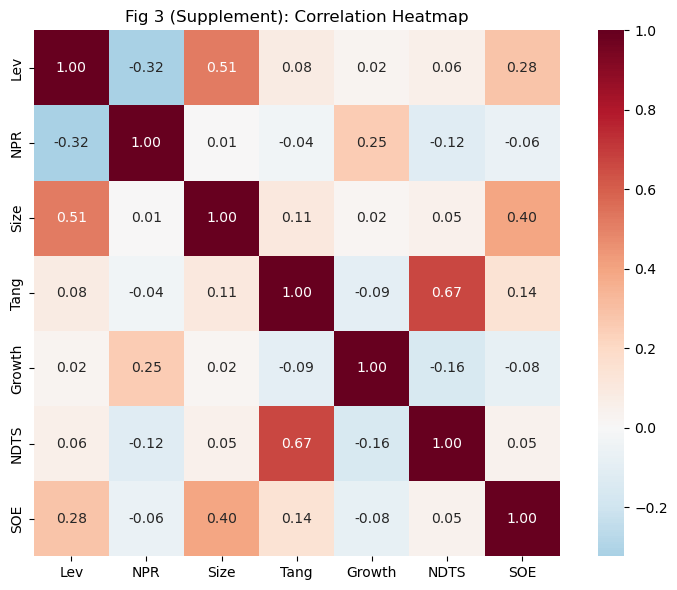

In [5]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
plt.title('Fig 3 (Supplement): Correlation Heatmap')
plt.tight_layout()
plt.savefig(OUT_FIG / 'Fig3_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## 2.3 时序趋势图

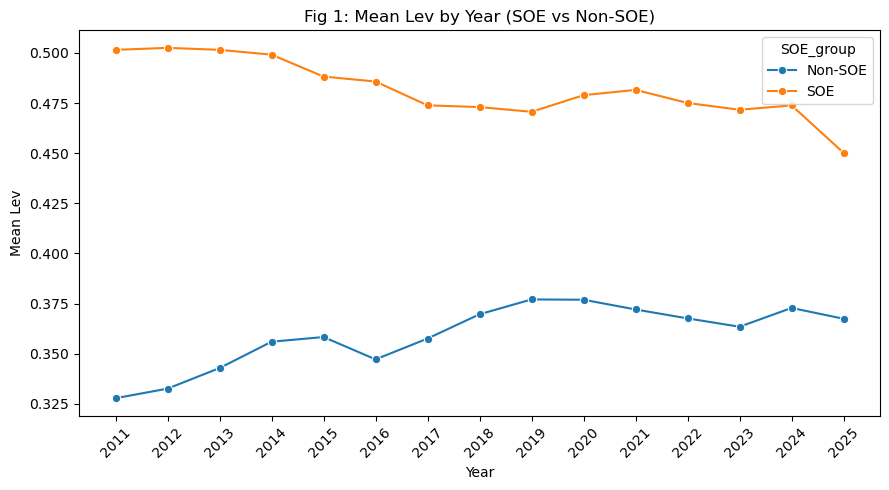

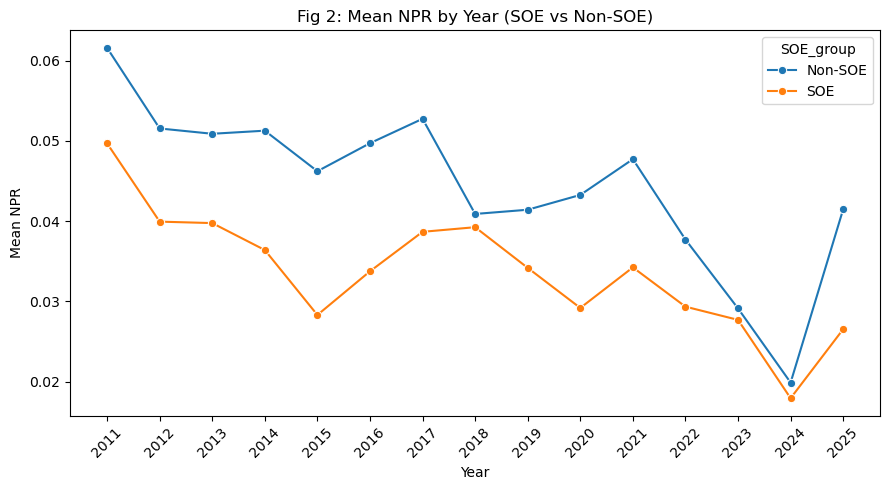

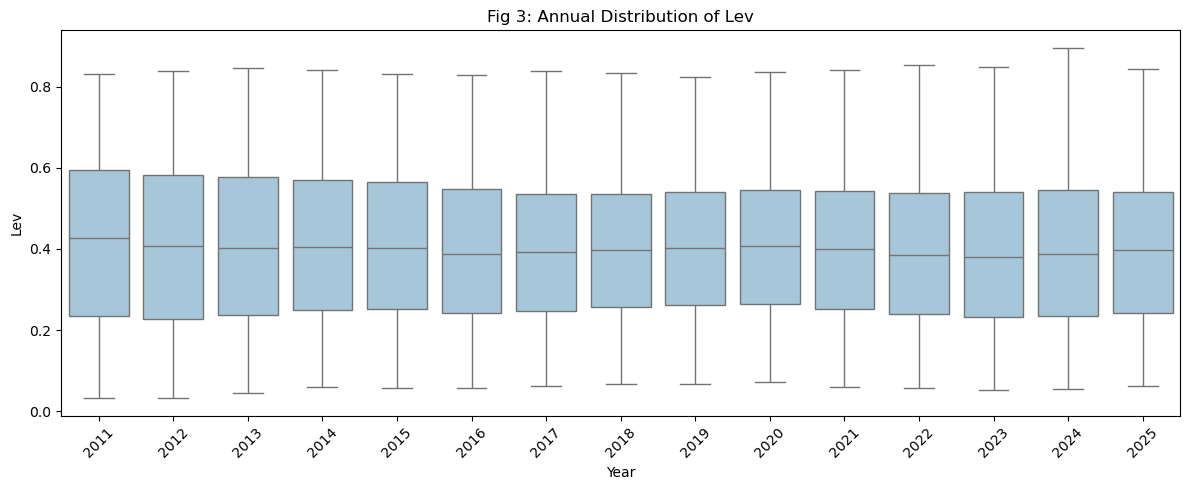

In [6]:
trend = (
    df[df['SOE'].isin([0, 1])]
    .groupby(['year', 'SOE'], as_index=False)[['Lev', 'NPR']]
    .mean()
)
trend['SOE_group'] = trend['SOE'].map({1.0: 'SOE', 0.0: 'Non-SOE'})

# 图1: Lev时序均值
plt.figure(figsize=(9, 5))
sns.lineplot(data=trend, x='year', y='Lev', hue='SOE_group', marker='o')
plt.title('Fig 1: Mean Lev by Year (SOE vs Non-SOE)')
plt.xlabel('Year')
plt.ylabel('Mean Lev')
plt.xticks(sorted(df['year'].dropna().unique()), rotation=45)
plt.tight_layout()
plt.savefig(OUT_FIG / 'Fig1_Lev_trend_SOE_vs_NonSOE.png', dpi=300, bbox_inches='tight')
plt.show()

# 图2: NPR时序均值
plt.figure(figsize=(9, 5))
sns.lineplot(data=trend, x='year', y='NPR', hue='SOE_group', marker='o')
plt.title('Fig 2: Mean NPR by Year (SOE vs Non-SOE)')
plt.xlabel('Year')
plt.ylabel('Mean NPR')
plt.xticks(sorted(df['year'].dropna().unique()), rotation=45)
plt.tight_layout()
plt.savefig(OUT_FIG / 'Fig2_NPR_trend_SOE_vs_NonSOE.png', dpi=300, bbox_inches='tight')
plt.show()

# 图3: Lev分年度箱型图
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='year', y='Lev', showfliers=False, color='#9ecae1')
plt.title('Fig 3: Annual Distribution of Lev')
plt.xlabel('Year')
plt.ylabel('Lev')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUT_FIG / 'Fig3_Lev_boxplot_by_year.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# 关键讨论提示（自动提取）
r_npr_lev = corr_matrix.loc['NPR', 'Lev']
r_size_npr = corr_matrix.loc['Size', 'NPR']
max_abs_offdiag = corr_matrix.where(~np.eye(corr_matrix.shape[0], dtype=bool)).abs().max().max()

print(f'NPR 与 Lev 相关系数: {r_npr_lev:.4f}')
print(f'Size 与 NPR 相关系数: {r_size_npr:.4f}')
print(f'非对角线最大绝对相关系数: {max_abs_offdiag:.4f}')
if max_abs_offdiag > 0.7:
    print('提示: 存在相关系数绝对值 > 0.7 的变量对，需关注潜在多重共线性。')
else:
    print('提示: 未发现相关系数绝对值 > 0.7 的变量对，多重共线性风险相对可控。')

print('\nSaved files:')
print('-', OUT_DATA / 'desc_stats_2_1_by_group.csv')
print('-', OUT_DATA / 'ttest_2_1_soe_vs_nonsoe.csv')
print('-', OUT_DATA / 'corr_matrix_2_2.csv')
print('-', OUT_DATA / 'corr_matrix_2_2_with_signif.csv')
print('-', OUT_FIG / 'Fig1_Lev_trend_SOE_vs_NonSOE.png')
print('-', OUT_FIG / 'Fig2_NPR_trend_SOE_vs_NonSOE.png')
print('-', OUT_FIG / 'Fig3_Lev_boxplot_by_year.png')

NPR 与 Lev 相关系数: -0.3231
Size 与 NPR 相关系数: 0.0069
非对角线最大绝对相关系数: 0.6676
提示: 未发现相关系数绝对值 > 0.7 的变量对，多重共线性风险相对可控。

Saved files:
- ../data/clean/desc_stats_2_1_by_group.csv
- ../data/clean/ttest_2_1_soe_vs_nonsoe.csv
- ../data/clean/corr_matrix_2_2.csv
- ../data/clean/corr_matrix_2_2_with_signif.csv
- ../output/figures/Fig1_Lev_trend_SOE_vs_NonSOE.png
- ../output/figures/Fig2_NPR_trend_SOE_vs_NonSOE.png
- ../output/figures/Fig3_Lev_boxplot_by_year.png
